# Agent Pick Rate & Win Rate

This notebook answers three questions using agent-level data: how often is each agent picked, how often do they win, and does that win rate shift depending on the map?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_csv('../data/processed/agent_level.csv')
df = df_raw.copy()

In [3]:
df.head()

,agent,map_name,won
0,Yoru,Bind,1
1,Raze,Bind,1
2,Brimstone,Bind,1
3,Viper,Bind,1
4,Fade,Bind,1


In [4]:
df.shape

(12700, 3)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12700 entries, 0 to 12699
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   agent     12700 non-null  str  
 1   map_name  12700 non-null  str  
 2   won       12700 non-null  int64
dtypes: int64(1), str(2)
memory usage: 297.8 KB


In [6]:
df.isna().sum()

agent       0
map_name    0
won         0
dtype: int64

## Pick Rate

Pick rate is calculated as each agent's row count divided by the total number of agent-selection instances in the dataset — since every row already represents one player's one agent choice on one map, no additional grouping is needed for the denominator.

In [7]:
pick_rate = (df.groupby('agent').size() / len(df)) * 100
pick_rate

agent
Astra         3.448819
Breach        5.141732
Brimstone     2.598425
Chamber       0.944882
Clove         0.307087
Cypher        6.330709
Deadlock      1.763780
Fade          6.047244
Gekko         1.149606
Harbor        0.519685
Iso           0.889764
Jett          4.173228
Kayo          3.039370
Killjoy       3.755906
Neon          4.724409
Omen         12.897638
Phoenix       0.212598
Raze          5.354331
Reyna         0.102362
Sage          0.724409
Skye          0.826772
Sova          7.992126
Tejo          5.700787
Viper         8.251969
Vyse          4.905512
Waylay        1.125984
Yoru          7.070866
dtype: float64

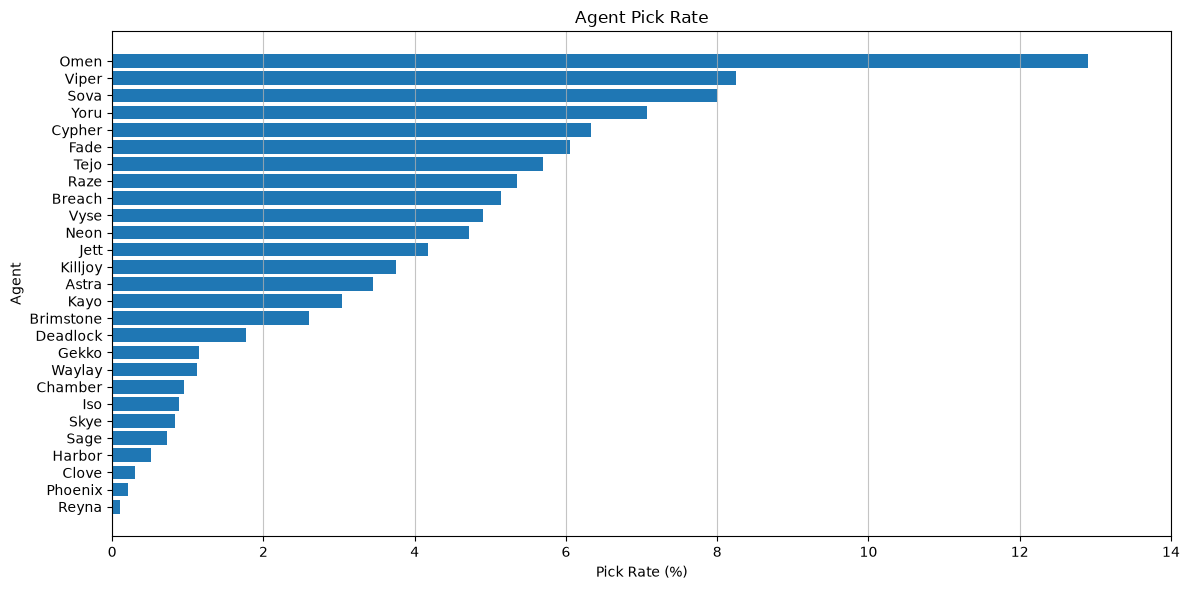

In [8]:
pick_rate_sorted = pick_rate.sort_values(ascending=True)

plt.figure(figsize=(12,6))

plt.title('Agent Pick Rate')
plt.barh(pick_rate_sorted.index, pick_rate_sorted.values)
plt.xlabel('Pick Rate (%)')
plt.xticks([x*2 for x in range(8)])
plt.ylabel('Agent')

plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

**Takeaway:** Omen is the clear standout, picked in roughly 13% of instances — nearly double the next-highest agents (Viper and Sova, both around 8%). Reyna and Phoenix sit at the opposite extreme, barely appearing at all, 
suggesting they're largely out of the current competitive meta. Most other agents cluster in a broad middle band between 2% and 6%.

## Win Rate

`won` is a boolean derived in the cleaning notebook by comparing a player's team against the map winner. Since `.mean()` on a boolean column returns the proportion of `True` values, grouping by agent and taking the mean of `won` gives each agent's win rate directly.

In [9]:
agent_win_rate = df.groupby('agent')['won'].mean() * 100
agent_win_rate

agent
Astra        49.771689
Breach       47.166922
Brimstone    50.303030
Chamber      55.833333
Clove        48.717949
Cypher       48.507463
Deadlock     45.982143
Fade         50.520833
Gekko        44.520548
Harbor       53.030303
Iso          49.557522
Jett         48.113208
Kayo         48.704663
Killjoy      50.733753
Neon         49.833333
Omen         49.572650
Phoenix      55.555556
Raze         51.470588
Reyna        38.461538
Sage         55.434783
Skye         47.619048
Sova         50.344828
Tejo         50.690608
Viper        51.431298
Vyse         51.524880
Waylay       48.951049
Yoru         51.224944
Name: won, dtype: float64

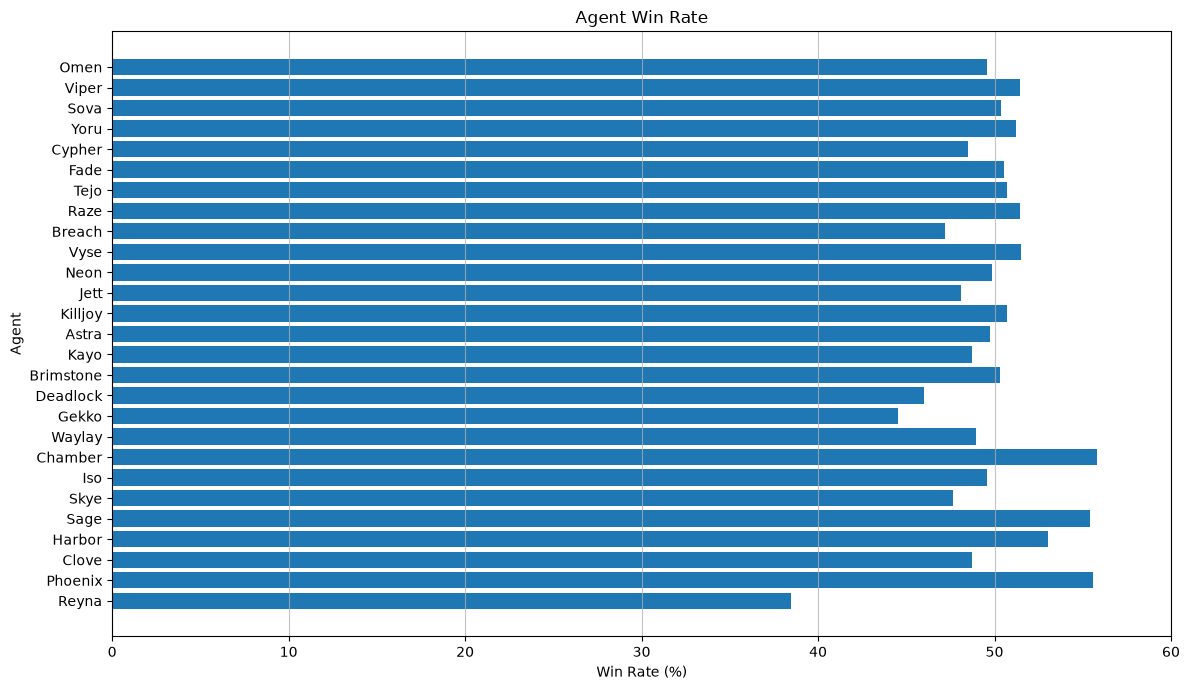

In [10]:
agent_win_rate_sorted = agent_win_rate.reindex(pick_rate_sorted.index)

plt.figure(figsize=(12,7))

plt.title('Agent Win Rate')
plt.barh(agent_win_rate_sorted.index, agent_win_rate_sorted.values)
plt.xlabel('Win Rate (%)')
plt.xticks([x*10 for x in range(7)])
plt.ylabel('Agent')

plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

**Takeaway:** Win rate is far more compressed than pick rate — nearly every agent sits within a narrow band of roughly 45-55%, regardless of how often they're picked. Phoenix and Chamber lead at around 55-56%, despite Phoenix being one of the least-picked agents overall, while Reyna sits lowest at around 38%. The lack of spread suggests win rate alone doesn't strongly separate agents the way pick rate does — worth keeping in mind heading into the composition-based modeling ahead.

## Win Rate by Map

In [11]:
agent_win_rate_by_map = df.groupby(['agent', 'map_name'])['won'].mean() * 100
agent_win_rate_by_map

agent  map_name
Astra  Abyss       47.500000
       Ascent      33.333333
       Bind        43.902439
       Corrode     55.555556
       Fracture    50.000000
                     ...    
Yoru   Icebox      28.571429
       Lotus       55.345912
       Pearl       50.400000
       Split       50.467290
       Sunset      52.380952
Name: won, Length: 238, dtype: float64

In [12]:
win_rate_grid = agent_win_rate_by_map.unstack()
win_rate_grid.head()

map_name,Abyss,Ascent,Bind,Corrode,Fracture,Haven,Icebox,Lotus,Pearl,Split,Sunset
agent,,,,,,,,,,,
Astra,47.500000,33.333333,43.902439,55.555556,50.000000,50.00,NaN,25.000000,50.259067,59.090909,NaN
Breach,61.111111,50.000000,50.000000,NaN,49.411765,43.75,0.000000,46.296296,25.000000,46.938776,50.0
Brimstone,NaN,NaN,50.920245,0.000000,50.000000,NaN,NaN,NaN,NaN,NaN,NaN
Chamber,40.000000,64.516129,NaN,57.142857,50.000000,100.00,44.444444,50.000000,60.714286,20.000000,75.0
Clove,NaN,75.000000,0.000000,50.000000,100.000000,50.00,0.000000,50.000000,NaN,NaN,50.0


In [13]:
pick_counts = df.groupby(['agent', 'map_name']).size().unstack()
pick_counts

map_name,Abyss,Ascent,Bind,Corrode,Fracture,Haven,Icebox,Lotus,Pearl,Split,Sunset
agent,,,,,,,,,,,
Astra,80.0,6.0,41.0,18.0,10.0,12.0,NaN,12.0,193.0,66.0,NaN
Breach,18.0,2.0,2.0,NaN,170.0,144.0,1.0,162.0,4.0,98.0,52.0
Brimstone,NaN,NaN,163.0,1.0,166.0,NaN,NaN,NaN,NaN,NaN,NaN
Chamber,10.0,31.0,NaN,14.0,8.0,1.0,9.0,10.0,28.0,5.0,4.0
Clove,NaN,4.0,2.0,4.0,1.0,2.0,2.0,22.0,NaN,NaN,2.0
Cypher,48.0,94.0,8.0,22.0,96.0,257.0,NaN,84.0,27.0,48.0,120.0
Deadlock,2.0,34.0,49.0,20.0,1.0,13.0,6.0,39.0,2.0,26.0,32.0
Fade,5.0,26.0,115.0,99.0,17.0,13.0,NaN,306.0,72.0,74.0,41.0
Gekko,2.0,1.0,74.0,12.0,2.0,NaN,54.0,NaN,NaN,NaN,1.0


In [14]:
for threshold in [x for x in range(11)]:
    flagged = (pick_counts < threshold).sum().sum()
    total_cells = pick_counts.notna().sum().sum()
    print(f"Threshold {threshold}: flags {flagged}/{total_cells} cells ({flagged/total_cells*100:.1f}%)")

Threshold 0: flags 0/238 cells (0.0%)
Threshold 1: flags 0/238 cells (0.0%)
Threshold 2: flags 20/238 cells (8.4%)
Threshold 3: flags 40/238 cells (16.8%)
Threshold 4: flags 50/238 cells (21.0%)
Threshold 5: flags 59/238 cells (24.8%)
Threshold 6: flags 66/238 cells (27.7%)
Threshold 7: flags 70/238 cells (29.4%)
Threshold 8: flags 73/238 cells (30.7%)
Threshold 9: flags 78/238 cells (32.8%)
Threshold 10: flags 84/238 cells (35.3%)


Extreme values (0% or 100%) are common in this grid but often reflect very small sample sizes rather than genuine performance patterns — a single game decides the entire "rate." Checking how many agent-map cells fall below a few candidate thresholds (5 games: 24.8%, 10: 35.3%, 15: 46.2%) showed no sharp natural cutoff, so 5 was chosen as a conservative floor — low enough to preserve most of the heatmap, while excluding the sample sizes most likely to produce a misleadingly clean 0% or 100% by chance. Cells below this threshold are marked with a dashed border.

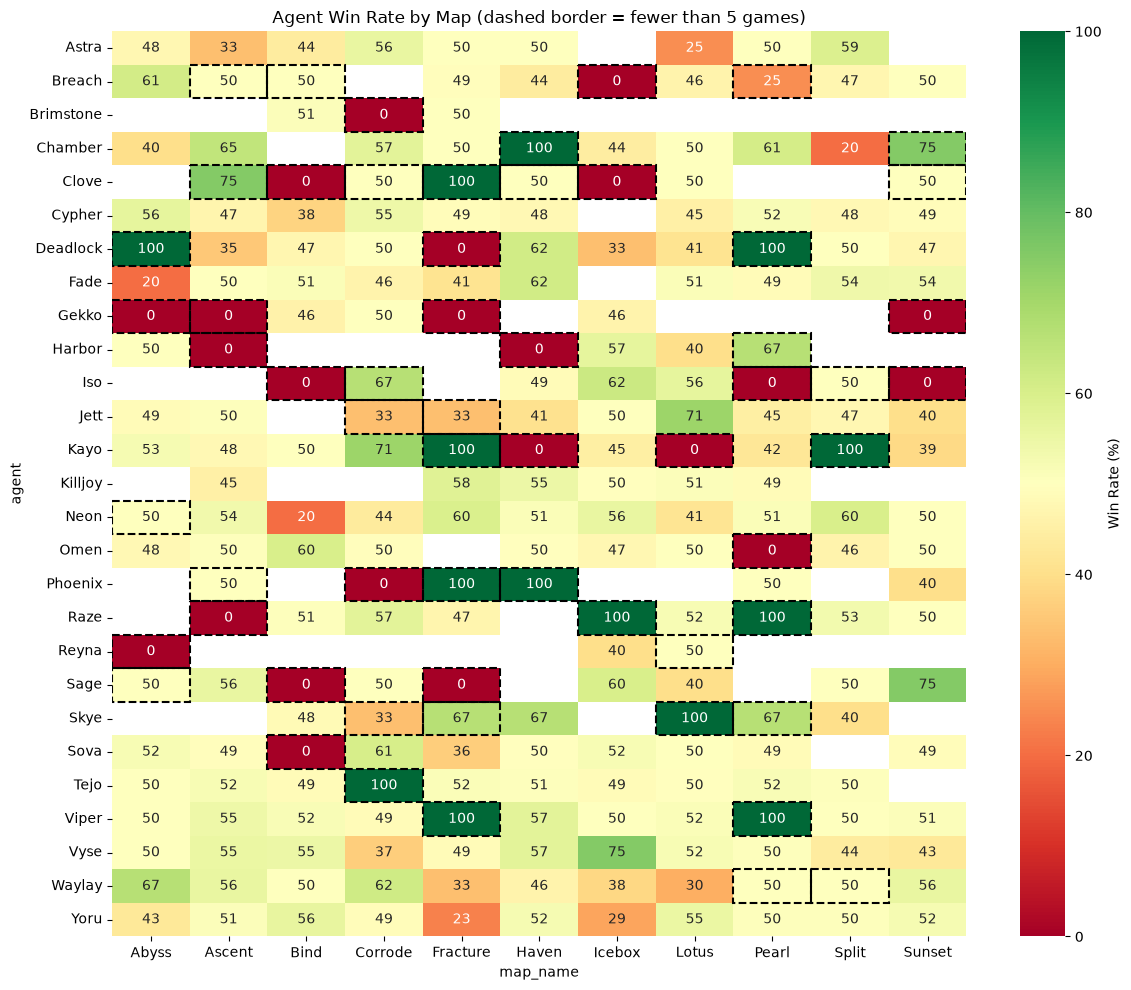

In [15]:
plt.figure(figsize=(12,10))

ax = sns.heatmap(win_rate_grid, annot=True, fmt='.0f', cmap='RdYlGn', cbar_kws={'label': 'Win Rate (%)'})

min_reliable = 5
for i in range(pick_counts.shape[0]):
    for j in range(pick_counts.shape[1]):
        count = pick_counts.values[i, j]
        if not np.isnan(count) and count < min_reliable:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', 
                                         linestyle='--', linewidth=1.5))

plt.title(f'Agent Win Rate by Map (dashed border = fewer than {min_reliable} games)')
plt.tight_layout()
plt.savefig('../figures/agent_win_rate_by_map.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** Win rate varies noticeably by map for several agents (e.g., Omen performs consistently across most maps with over 100 games each, while agents like Gekko or Phoenix show extreme swings — 0% or 100% on some maps). However, many of the most extreme values come from very low pick counts on that agent-map combination (sometimes just 1-2 games), making them unreliable as genuine performance signals rather than small-sample noise. Cells with substantial sample sizes (roughly 50+ games), like Omen, Sova, and Viper across most maps, are more trustworthy reads of actual map-specific performance.

## Summary

Pick rate and win rate tell different stories — Omen dominates in picks but sits mid-pack in win rate, while several rarely-picked agents (Phoenix, Chamber) actually win more often when chosen. Win rate by map adds a further layer: even agents with a solid overall win rate can swing widely depending on the map, though many of the most extreme swings come from small sample sizes rather than real performance differences.